# Prediksi Data UMR Jakarta

In [ ]:
# IMPORT FILE
import pandas as pd
import numpy as np
from google.colab import files
import io

print("Upload file Excel UMR Jakarta:")
uploaded = files.upload()

# Ambil nama file
filename = next(iter(uploaded))
print(f"File '{filename}' berhasil diupload.")

# Load data
try:
    df_umr_raw = pd.read_excel(io.BytesIO(uploaded[filename]))
    print("\n5 Baris Teratas Data Mentah:")
    display(df_umr_raw.head())
except Exception as e:
    print(f"Error membaca file: {e}")

Upload file Excel UMR Jakarta:


Saving UMR_Jakarta.xlsx to UMR_Jakarta.xlsx
File 'UMR_Jakarta.xlsx' berhasil diupload.

5 Baris Teratas Data Mentah:


,TAHUN,Upah Minimum Provinsi (UMP) DKI Jakarta (Rupiah)
0,2025,5396761
1,2024,5067381
2,2023,4901798
3,2022,4573845
4,2021,4416187


Data Historis UMR (Bersih):


,Tahun,UMR
0,2012,1529150
1,2013,2200000
2,2014,2441000
3,2015,2700000
4,2016,3100000


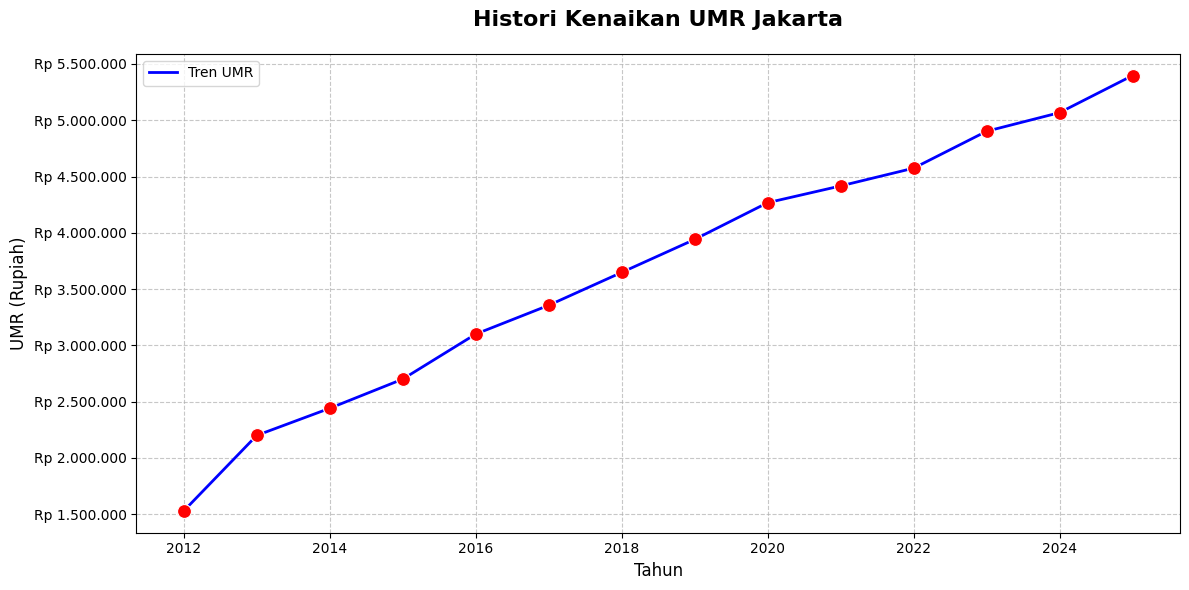

In [ ]:
# PREPROCESSING DAN VISUALISASI AWAL

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# --- 1. PREPROCESSING
df_umr = df_umr_raw.copy()

# Rename Kolom
df_umr.columns = ['Tahun', 'UMR']

# Cleaning Kolom Tahun
df_umr['Tahun'] = pd.to_numeric(df_umr['Tahun'], errors='coerce').astype(int)

# Cleaning Kolom UMR
# Menghapus 'Rp', titik, koma, dan spasi, lalu ubah ke integer
df_umr['UMR'] = df_umr['UMR'].astype(str).str.replace(r'[Rp,.\s]', '', regex=True)
df_umr['UMR'] = pd.to_numeric(df_umr['UMR'], errors='coerce')

# Sorting & Reset Index
df_umr = df_umr.sort_values('Tahun').reset_index(drop=True)

# Tampilkan data bersih
print("Data Historis UMR (Bersih):")
display(df_umr.head())

# --- 2. VISUALISASI DATA HISTORIS
plt.figure(figsize=(12, 6))

# Membuat Line Plot dan Scatter Plot
sns.lineplot(data=df_umr, x='Tahun', y='UMR', color='blue', linewidth=2, label='Tren UMR')
sns.scatterplot(data=df_umr, x='Tahun', y='UMR', color='red', s=100, zorder=5)

# --- Formatting Visualisasi ---
plt.title('Histori Kenaikan UMR Jakarta', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('UMR (Rupiah)', fontsize=12)

# Format Sumbu Y menjadi Rupiah
#  lambda function untuk format ribuan dengan titik
formatter = ticker.FuncFormatter(lambda x, p: f'Rp {x:,.0f}'.replace(',', '.'))
plt.gca().yaxis.set_major_formatter(formatter)

# Sumbu X hanya menampilkan tahun bulat (integer)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Tampilkan Plot
plt.show()

In [ ]:
# LATIH MODEL
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

def train_umr_model(df):
    # Menyiapkan data (X harus 2D array)
    X = df[['Tahun']].values
    y = df['UMR'].values

    # Inisialisasi dan Pelatihan
    model = LinearRegression()
    model.fit(X, y)

    # Evaluasi Sederhana
    r2 = model.score(X, y)
    slope = model.coef_[0]
    intercept = model.intercept_

    print("=== Model  Dilatih ===")
    print(f"R-Squared: {r2:.4f}")
    print(f"Kenaikan Tahunan: Rp {slope:,.0f}")
    print(f"Persamaan: UMR = {intercept:.0f} + {slope:.0f} * Tahun")

    return model

In [ ]:
# PREDICT FUNCTION
def predict_future_umr(model, df_original, end_year_pred):
    # Ambil tahun awal dari data asli
    min_year = df_original['Tahun'].min()

    # Buat range tahun untuk prediksi (dari awal data sampai target)
    future_years = np.arange(min_year, end_year_pred + 1).reshape(-1, 1)

    # Lakukan Prediksi
    y_future_pred = model.predict(future_years)

    # Susun ke dalam DataFrame
    df_result = pd.DataFrame({
        'Tahun': future_years.flatten(),
        'UMR_Prediksi': y_future_pred.astype(int)
    })

    # Gabungkan dengan data asli untuk perbandingan Aktual vs Prediksi
    df_result = pd.merge(df_result, df_original, on='Tahun', how='left')
    df_result.rename(columns={'UMR': 'UMR_Aktual'}, inplace=True)

    return df_result

In [ ]:
# Latih Model
model_umr = train_umr_model(df_umr)

# Prediksi
df_proyeksi = predict_future_umr(model_umr, df_umr, 2030)

# Tampilkan hasil
print("\nHasil Proyeksi UMR:")
display(df_proyeksi.tail(10))

=== Model  Dilatih ===
R-Squared: 0.9869
Kenaikan Tahunan: Rp 278,446
Persamaan: UMR = -558361820 + 278446 * Tahun

Hasil Proyeksi UMR:


,Tahun,UMR_Prediksi,UMR_Aktual
9,2021,4377416,4416187.0
10,2022,4655862,4573845.0
11,2023,4934308,4901798.0
12,2024,5212754,5067381.0
13,2025,5491200,5396761.0
14,2026,5769646,NaN
15,2027,6048092,NaN
16,2028,6326538,NaN
17,2029,6604984,NaN
18,2030,6883430,NaN


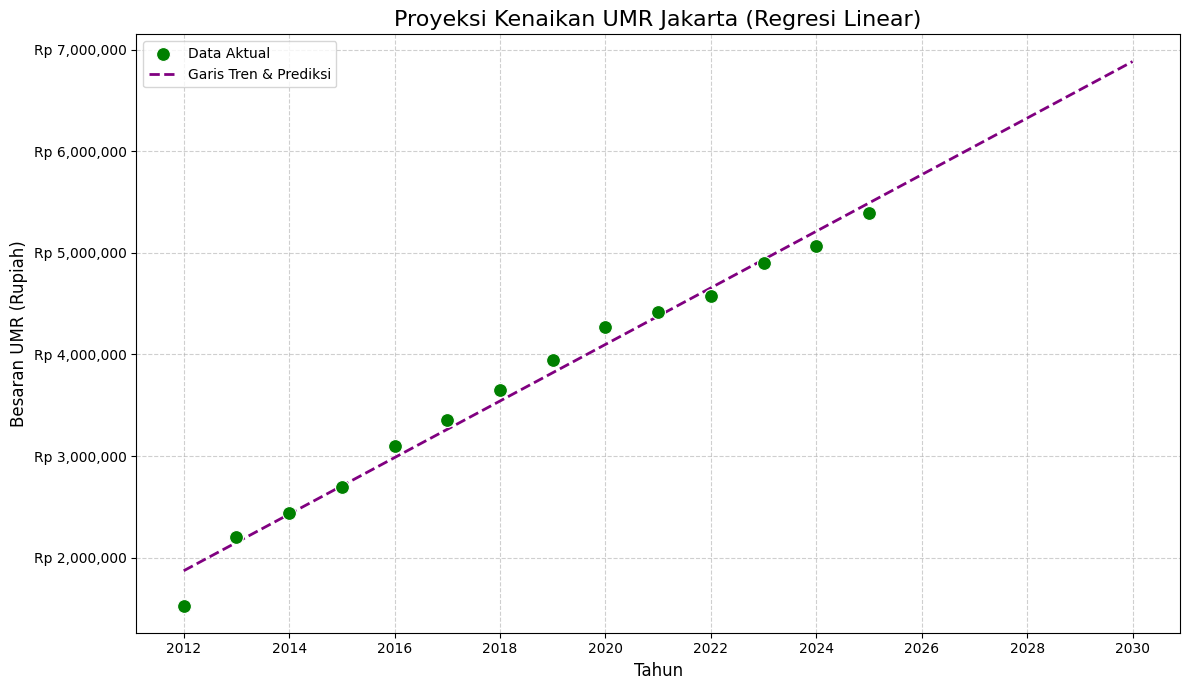

In [ ]:
plt.figure(figsize=(12, 7))

# Plot Data Aktual (Titik Hijau)
sns.scatterplot(
    x=df_proyeksi['Tahun'],
    y=df_proyeksi['UMR_Aktual'],
    color='green',
    s=100,
    label='Data Aktual',
    zorder=5
)

# Plot Garis Regresi (Garis Ungu)
plt.plot(
    df_proyeksi['Tahun'],
    df_proyeksi['UMR_Prediksi'],
    color='purple',
    linewidth=2,
    linestyle='--',
    label='Garis Tren & Prediksi'
)

# Formatting
plt.title('Proyeksi Kenaikan UMR Jakarta (Regresi Linear)', fontsize=16)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Besaran UMR (Rupiah)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Format Sumbu Y menjadi Rupiah (Jutaan)
# Fungsi ini mengubah 5000000 menjadi "5.0 Jt" atau format angka biasa
def currency_formatter(x, pos):
    return f'Rp {x:,.0f}'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(currency_formatter))

# Pastikan sumbu X menampilkan tahun bulat
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# Prediksi Data Kurs (Dollar/Rupiah)

In [ ]:
# IMPORT
import pandas as pd
from google.colab import files

print("Upload Kurs USD/IDR")
kurs_uploaded = files.upload()

kurs_file_path = next(iter(kurs_uploaded))
print(f"File '{kurs_file_path}' uploaded successfully.")

df_kurs_excel = pd.read_excel(kurs_file_path)

print(f"\nSuccessfully loaded '{kurs_file_path}'. 5 baris awal:")
display(df_kurs_excel.head())

print("\nDataFrame Info:")
df_kurs_excel.info()

Upload Kurs USD/IDR


Saving Kurs Transaksi USD.xlsx to Kurs Transaksi USD.xlsx
File 'Kurs Transaksi USD.xlsx' uploaded successfully.

Successfully loaded 'Kurs Transaksi USD.xlsx'. 5 baris awal:


,NO,Nilai,Kurs Jual,Kurs Beli,Tanggal
0,1,1,16873.95,16706.05,12/24/2025 12:00:00 AM
1,2,1,16856.87,16689.13,12/23/2025 12:00:00 AM
2,3,1,16818.67,16651.33,12/22/2025 12:00:00 AM
3,4,1,16805.61,16638.39,12/19/2025 12:00:00 AM
4,5,1,16781.49,16614.51,12/18/2025 12:00:00 AM



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6102 entries, 0 to 6101
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   NO         6102 non-null   int64  
 1   Nilai      6102 non-null   int64  
 2   Kurs Jual  6102 non-null   float64
 3   Kurs Beli  6102 non-null   float64
 4   Tanggal    6102 non-null   object 
dtypes: float64(2), int64(2), object(1)
memory usage: 238.5+ KB


/tmp/ipython-input-615496644.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_kurs['Tanggal'] = pd.to_datetime(df_kurs['Tanggal'])


Data berhasil diubah menjadi Bulanan (5 baris pertama):


,Kurs_Jual_Aktual
Tanggal,
2001-01-31,9482.500000
2001-02-28,9679.100000
2001-03-31,10255.750000
2001-04-30,11130.000000
2001-05-31,11347.714286


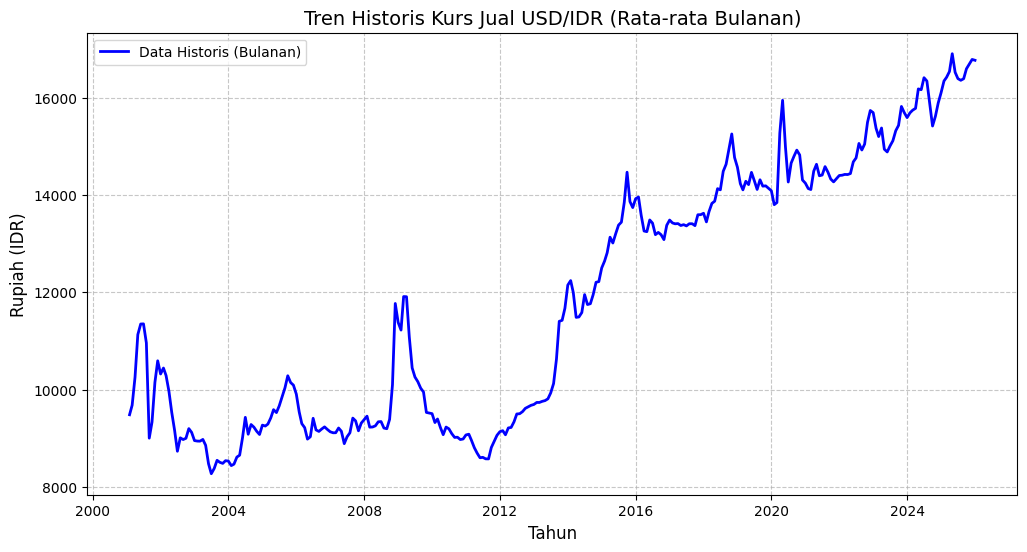

In [ ]:
# preprocessing dan visualisasi data awal
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error

df_kurs = df_kurs_excel.copy()

df_kurs['Tanggal'] = pd.to_datetime(df_kurs['Tanggal'])
df_kurs = df_kurs.set_index('Tanggal')
df_kurs = df_kurs.sort_index() # Urutkan tanggal terlama ke terbaru

# Ubah data harian menjadi bulanan
# Kita ambil rata-rata kurs ('mean') setiap bulannya
# 'ME' artinya Month End (Akhir Bulan)
df_bulanan = df_kurs['Kurs Jual'].resample('ME').mean().to_frame()
df_bulanan.columns = ['Kurs_Jual_Aktual']

print("Data berhasil diubah menjadi Bulanan (5 baris pertama):")
display(df_bulanan.head())

# VISUALISASI DATA HISTORIS BULANAN
plt.figure(figsize=(12, 6))
plt.plot(df_bulanan.index, df_bulanan['Kurs_Jual_Aktual'], label='Data Historis (Bulanan)', color='blue', linewidth=2)
plt.title('Tren Historis Kurs Jual USD/IDR (Rata-rata Bulanan)', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Rupiah (IDR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:

from statsmodels.tsa.holtwinters import ExponentialSmoothing #ExponentialSmoothing

# 1. Siapkan Data
data_kurs = df_bulanan['Kurs_Jual_Aktual'].dropna()

# 2. Membuat Model dengan Parameter Khusus
# trend='add'  -> Memaksa model menggunakan tren penambahan (Garis lurus naik/turun)
# damped_trend=False -> JANGAN redam trennya. Biarkan dia naik terus.
# initialization_method='estimated' -> Biarkan library mencari titik awal terbaik
# Using ExponentialSmoothing which explicitly supports 'trend' and 'damped_trend' arguments.
# For a simple Holt's method (linear trend, no seasonality), seasonal should be None.
model_holt = ExponentialSmoothing(data_kurs, trend='add', damped_trend=False, seasonal=None, initialization_method='estimated')

# Latih model
model_fit = model_holt.fit(optimized=True)

# Cek parameter yang ditemukan komputer (untuk debug)
print(f"Level Smoothing (alpha): {model_fit.params['smoothing_level']}")
print(f"Trend Smoothing (beta): {model_fit.params['smoothing_trend']}")
# Jika beta sangat kecil (dekat 0), berarti dia menganggap tidak ada tren.

Level Smoothing (alpha): 0.9999999850988388
Trend Smoothing (beta): 0.0


In [ ]:
# 3. Prediksi
n_bulan_depan = 60
prediksi_holt = model_fit.forecast(n_bulan_depan)

In [ ]:

# 4. Buat DataFrame Hasil
last_date = data_kurs.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_bulan_depan, freq='ME')

df_prediksi_final = pd.DataFrame({
    'Tanggal': future_dates,
    'Kurs_Prediksi': prediksi_holt.values
})
df_prediksi_final.set_index('Tanggal', inplace=True)

# Tampilkan data awal (Harusnya sekarang angkanya berubah naik)
print("\nHasil Prediksi (5 Bulan Pertama):")
display(df_prediksi_final.head())



Hasil Prediksi (5 Bulan Pertama):


,Kurs_Prediksi
Tanggal,
2026-01-31,16784.357851
2026-02-28,16799.340702
2026-03-31,16814.323553
2026-04-30,16829.306403
2026-05-31,16844.289254


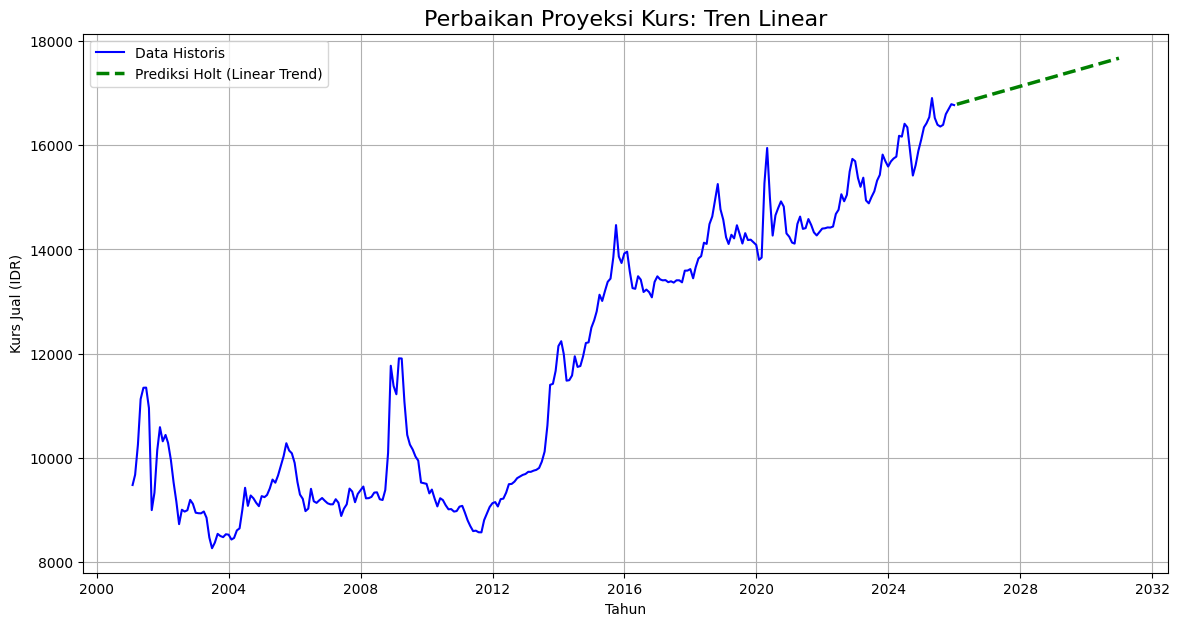

In [ ]:

# 5. Visualisasi
plt.figure(figsize=(14, 7))
plt.plot(data_kurs.index, data_kurs, label='Data Historis', color='blue')
plt.plot(df_prediksi_final.index, df_prediksi_final['Kurs_Prediksi'],
         label='Prediksi Holt (Linear Trend)', color='green', linewidth=2.5, linestyle='--')

plt.title('Perbaikan Proyeksi Kurs: Tren Linear', fontsize=16)
plt.xlabel('Tahun')
plt.ylabel('Kurs Jual (IDR)')
plt.legend()
plt.grid(True)
plt.show()

# Prediksi Data Emas dengan Metode Monte Carlo


In [ ]:
# DEFINITOIN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

%matplotlib inline

# Nama file sesuai input Anda
file_input = 'Data Historis Emas Berjangka.xlsx'

# Variabel Konversi
GRAM_PER_OZ = 31.1035

In [ ]:
# IMPORT FILE
from google.colab import files
import io

print("Upload file data emas:")
uploaded = files.upload()

# Ambil nama file
filename = next(iter(uploaded))
print(f"File '{filename}' berhasil diupload.")

# Load data
try:
    df_emas_raw = pd.read_csv(io.BytesIO(uploaded[filename]))
    print("\n5 Baris Teratas Data Mentah:")
    display(df_emas_raw.head())
except Exception as e:
    print(f"Error membaca file: {e}")

Upload file data emas:


Saving Data Historis Emas Berjangka.csv to Data Historis Emas Berjangka.csv
File 'Data Historis Emas Berjangka.csv' berhasil diupload.

5 Baris Teratas Data Mentah:


,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,01/11/2025,"4.256,40","3.994,40","4.262,50","3.937,55","3,07M","6,06%"
1,01/10/2025,"4.013,30","3.887,70","4.398,00","3.842,80","7,42M","3,62%"
2,01/09/2025,"3.873,20","3.499,40","3.899,20","3.493,90","585,10K","10,57%"
3,01/08/2025,"3.502,80","3.314,60","3.505,30","3.304,00","260,88K","5,47%"
4,01/07/2025,"3.321,10","3.339,50","3.466,50","3.292,50","65,11K","-0,04%"


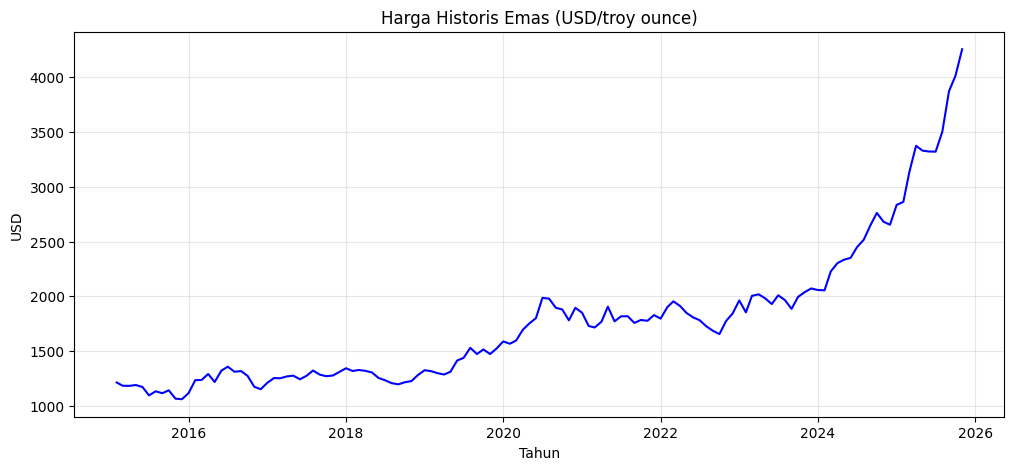

Data Preprocessing Selesai.


,Harga_USD_oz
Tanggal,
2025-07-01,3321.1
2025-08-01,3502.8
2025-09-01,3873.2
2025-10-01,4013.3
2025-11-01,4256.4


In [ ]:
# PREPROCESSING DAN VISUALISASI AWAL
df_emas = df_emas_raw.copy()

# Rename Kolom Harga
rename_map = {'Terakhir': 'Harga_USD_oz', 'Price': 'Harga_USD_oz', 'Last': 'Harga_USD_oz'}
for col_old, col_new in rename_map.items():
    if col_old in df_emas.columns:
        df_emas = df_emas.rename(columns={col_old: col_new})

# 3. Pembersihan format angka (Mengubah 4.256,40 menjadi 4256.40)
if df_emas['Harga_USD_oz'].dtype == 'object':
    df_emas['Harga_USD_oz'] = df_emas['Harga_USD_oz'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df_emas['Harga_USD_oz'] = pd.to_numeric(df_emas['Harga_USD_oz'], errors='coerce')

# 4. Konversi Tanggal
df_emas['Tanggal'] = pd.to_datetime(df_emas['Tanggal'], dayfirst=True)
df_emas = df_emas.sort_values('Tanggal')
df_emas = df_emas.dropna(subset=['Harga_USD_oz'])
df_emas.set_index('Tanggal', inplace=True)

# 5. Visualisasi Awal (USD/oz)
plt.figure(figsize=(12, 5))
plt.plot(df_emas['Harga_USD_oz'], color='blue', linewidth=1.5)
plt.title('Harga Historis Emas (USD/troy ounce)')
plt.ylabel('USD')
plt.xlabel('Tahun')
plt.grid(True, alpha=0.3)
plt.show()

print("Data Preprocessing Selesai.")
display(df_emas[['Harga_USD_oz']].tail())

In [ ]:
def jalankan_monte_carlo(data_series, target_year, n_simulasi=1000):
    log_returns = np.log(1 + data_series.pct_change())
    u = log_returns.mean()
    var = log_returns.var()
    stdev = log_returns.std()
    drift = u - (0.5 * var)

    last_date = data_series.index[-1]
    months_to_forecast = (target_year - last_date.year) * 12 + (12 - last_date.month)

    Z = np.random.standard_normal((months_to_forecast, n_simulasi))
    periodic_returns = np.exp(drift + stdev * Z)

    pred_path = np.zeros_like(periodic_returns)
    pred_path[0] = data_series.iloc[-1]

    for t in range(1, months_to_forecast):
        pred_path[t] = pred_path[t - 1] * periodic_returns[t]

    forecast_dates = [last_date + pd.DateOffset(months=i) for i in range(1, months_to_forecast + 1)]
    return forecast_dates, pred_path, months_to_forecast

In [ ]:
# Jalankan simulasi
dates_future, results_usd, n_bulan_depan = jalankan_monte_carlo(df_emas['Harga_USD_oz'], 2030)
mean_prediction_usd = np.mean(results_usd, axis=1)

print(f"Simulasi Monte Carlo untuk {n_bulan_depan} bulan selesai.")

Simulasi Monte Carlo untuk 61 bulan selesai.


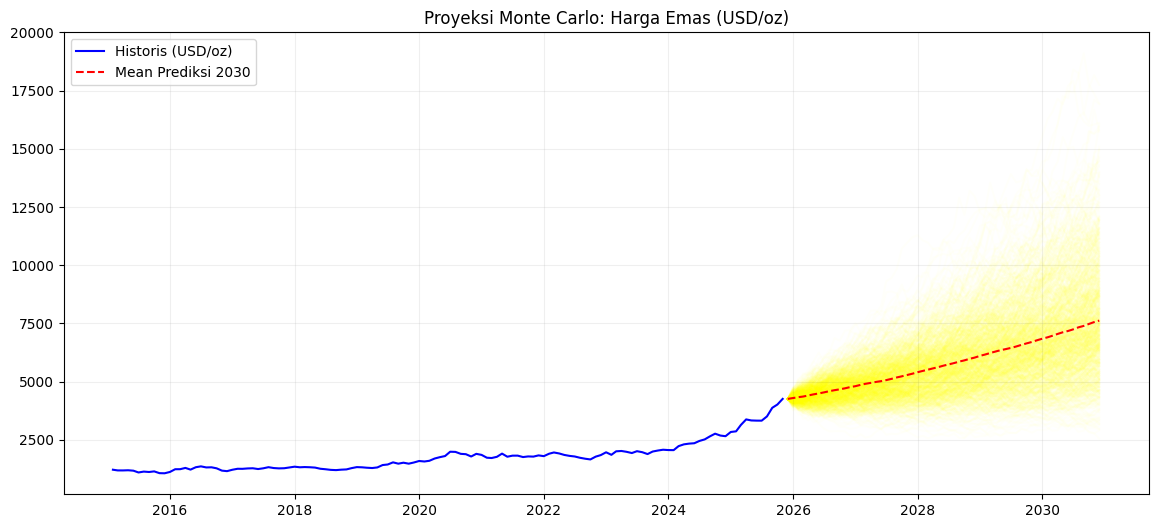

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(dates_future, results_usd, color='yellow', alpha=0.02)
plt.plot(df_emas.index, df_emas['Harga_USD_oz'], color='blue', label='Historis (USD/oz)')
plt.plot(dates_future, mean_prediction_usd, color='red', linestyle='--', label='Mean Prediksi 2030')
plt.title('Proyeksi Monte Carlo: Harga Emas (USD/oz)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
def dapatkan_prediksi_tahunan(target_year, n_simulasi=1000):
    # Jalankan Monte Carlo (USD/oz)
    dates_future, results_usd, n_bulan = jalankan_monte_carlo(df_emas['Harga_USD_oz'], target_year, n_simulasi)

    # model memprediksi jumlah bulan yang SAMA dengan Monte Carlo
    prediksi_kurs_dynamic = model_fit.forecast(n_bulan)
    kurs_values = prediksi_kurs_dynamic.values.reshape(-1, 1)

    # Konversi ke IDR/Gram
    GRAM_PER_OZ = 31.1035
    results_idr_gr = (results_usd * kurs_values) / GRAM_PER_OZ

    # Hitung Rata-Rata per Bulan (Mean dari semua simulasi yang dilakukan montecarlo)
    # jadi pada bulan tertentu monte carlo memperkirakana beberapa kemungkinan, dan ini adalah rata-ratanya
    mean_monthly_idr = np.mean(results_idr_gr, axis=1)

    # 5. Buat DataFrame untuk mempermudah filter tahun
    df_res = pd.DataFrame({
        'Tanggal': dates_future,
        'Harga_IDR_gr': mean_monthly_idr
    })

    # 6. Hitung Rata-Rata 12 Bulan pada tahun target
    df_target = df_res[df_res['Tanggal'].dt.year == target_year]

    if not df_target.empty:
        rata_rata_tahunan = df_target['Harga_IDR_gr'].mean()
    else:
        rata_rata_tahunan = mean_monthly_idr[-1]
        print(f"Peringatan: Tahun {target_year} tidak terjangkau sepenuhnya.")

    return dates_future, results_idr_gr, rata_rata_tahunan

print("Fungsi Prediksi Tahunan Berhasil Diperbaiki.")

Fungsi Prediksi Tahunan Berhasil Diperbaiki.


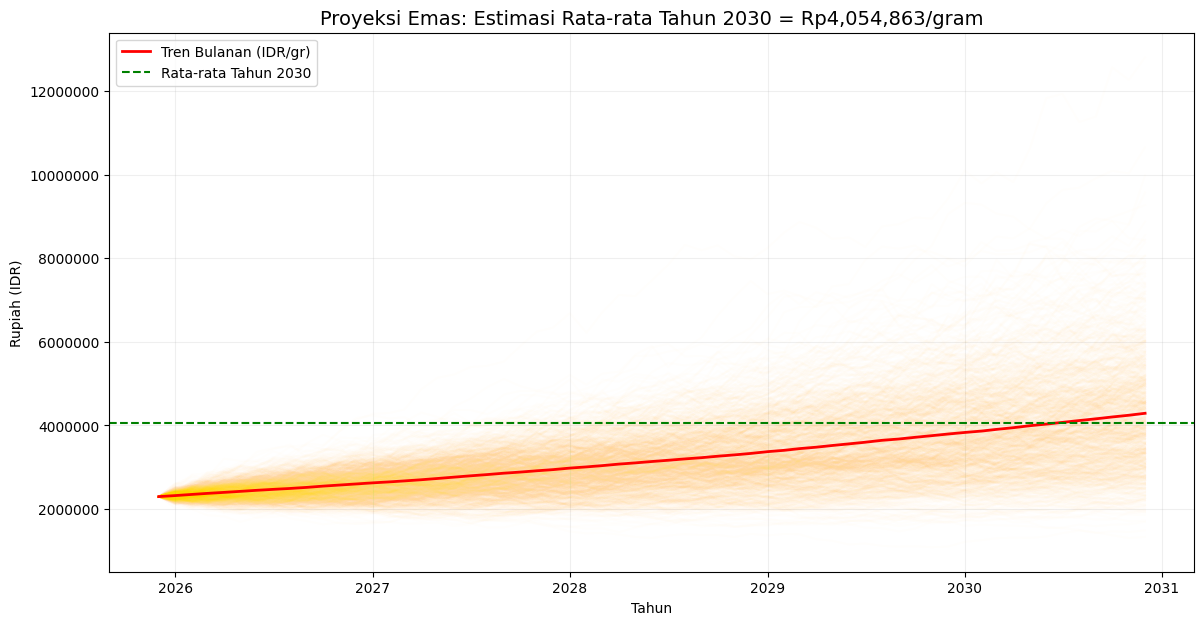

--- ANALISIS HARGA ---
Berdasarkan simulasi, rata-rata harga emas di tahun 2030 diprediksi sebesar:
Rp4,054,863.31 per Gram


In [ ]:
# Tentukan tahun target
tahun_target = 2030

# Jalankan fungsi
dates_future, results_idr, avg_target = dapatkan_prediksi_tahunan(tahun_target)



# Visualisasi
plt.figure(figsize=(14, 7))

# Plot cloud simulasi (IDR/gr)
plt.plot(dates_future, results_idr, color='gold', alpha=0.01)

# Plot rata-rata bulanan
plt.plot(dates_future, np.mean(results_idr, axis=1), color='red', label='Tren Bulanan (IDR/gr)', linewidth=2)

# Garis rata-rata tahunan
plt.axhline(y=avg_target, color='green', linestyle='--', label=f'Rata-rata Tahun {tahun_target}')

plt.title(f'Proyeksi Emas: Estimasi Rata-rata Tahun {tahun_target} = Rp{avg_target:,.0f}/gram', fontsize=14)
plt.ylabel('Rupiah (IDR)')
plt.xlabel('Tahun')
plt.legend()
plt.grid(True, alpha=0.2)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

print(f"--- ANALISIS HARGA ---")
print(f"Berdasarkan simulasi, rata-rata harga emas di tahun {tahun_target} diprediksi sebesar:")
print(f"Rp{avg_target:,.2f} per Gram")

In [ ]:
# Buat DataFrame untuk menampilkan hasil bulanan
df_monthly_projection = pd.DataFrame({
    'Tanggal': dates_future,
    'Harga_Emas_IDR_per_Gram': np.mean(results_idr, axis=1)
})

print("5 baris teratas dari proyeksi bulanan emas (IDR/Gram):")
display(df_monthly_projection.head())

5 baris teratas dari proyeksi bulanan emas (IDR/Gram):


,Tanggal,Harga_Emas_IDR_per_Gram
0,2025-12-01,2.296878e+06
1,2026-01-01,2.321798e+06
2,2026-02-01,2.349502e+06
3,2026-03-01,2.373995e+06
4,2026-04-01,2.397899e+06


# Prediksi Data Haji dengan Metode Logistik


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from google.colab import files

# 1. Upload File
print("Silakan upload file 'data_haji.xlsx'")
uploaded = files.upload()

# 2. Load Data
df_histori = pd.read_excel(next(iter(uploaded)))
print("\nData Historis Berhasil Dimuat:")
print(df_histori.head())

Silakan upload file 'data_haji.xlsx'


Saving data reguler, haji plus & furoda 2014-2025.xlsx to data reguler, haji plus & furoda 2014-2025.xlsx

Data Historis Berhasil Dimuat:
   Tahun  DP haji regular  nilai manfaat haji regular  \
0   2014         25000000                    19240000   
1   2015         25000000                    24070000   
2   2016         25000000                    25400000   
3   2017         25000000                    26900000   
4   2018         25000000                    33720000   

   Sisa biaya haji regular  Total haji regular  \
0                 15030000            59270000   
1                 12490000            61560000   
2                  9600000            60000000   
3                  9890000            61790000   
4                 10240000            68960000   

                                              sumber  DP haji plus  \
0  https://bpkh.go.id/publikasi/siaran-pers/kontr...          4000   
1  https://bpkh.go.id/publikasi/siaran-pers/kontr...          4000   
2  https

In [ ]:
df_histori.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Tahun                            12 non-null     int64 
 1   DP haji regular                  12 non-null     int64 
 2   nilai manfaat haji regular       12 non-null     int64 
 3   Sisa biaya haji regular          12 non-null     int64 
 4   Total haji regular               12 non-null     int64 
 5   sumber                           12 non-null     object
 6   DP haji plus                     12 non-null     int64 
 7   nilai manfaat haji plus          12 non-null     int64 
 8   Total Biaya Haji Plus (Rupiah)   12 non-null     int64 
 9   Referensi/Sumber                 12 non-null     object
 10  Total Biaya Haji Furoda          12 non-null     object
 11  Referensi/Sumber.1               12 non-null     object
dtypes: int64(8), object(4)
memory usage: 1

In [ ]:
# 1. Membersihkan data Haji Reguler
df_histori['Total haji regular'] = pd.to_numeric(df_histori['Total haji regular'], errors='coerce')

# 2. Membersihkan data Haji Furoda (Menghapus '-' dan ubah ke numerik)
df_histori['Total Biaya Haji Furoda'] = pd.to_numeric(df_histori['Total Biaya Haji Furoda'], errors='coerce')

# 3. Menyiapkan data untuk fitting Reguler (Semua tahun dari 2014)
df_reg_clean = df_histori.dropna(subset=['Total haji regular'])
t_reg = df_reg_clean['Tahun'].values - df_reg_clean['Tahun'].min()
y_reg = df_reg_clean['Total haji regular'].values

# 4. Menyiapkan data untuk fitting Furoda (Hanya tahun yang ada datanya)
df_fur_clean = df_histori.dropna(subset=['Total Biaya Haji Furoda'])
t_fur = df_fur_clean['Tahun'].values - df_histori['Tahun'].min() # Tetap gunakan referensi tahun awal 2014
y_fur = df_fur_clean['Total Biaya Haji Furoda'].values

print("Data siap untuk diproses fitting.")

Data siap untuk diproses fitting.


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# 1. Definisi Model Pertumbuhan Logistik
# Model ini dipilih karena biaya haji memiliki batasan daya beli dan regulasi pemerintah (Carrying Capacity)
def logistic_model(t, K, r, P0):
    return K / (1 + ((K - P0) / P0) * np.exp(-r * t))

# --- PREPARASI DATA ---
# t=0 diasumsikan tahun 2014 sesuai titik awal data haji reguler
t_reg = df_reg_clean['Tahun'].values - 2014
y_reg = df_reg_clean['Total haji regular'].values

t_fur = df_fur_clean['Tahun'].values - 2014
y_fur = df_fur_clean['Total Biaya Haji Furoda'].values

# --- TUNING & JUSTIFIKASI PARAMETER HAJI REGULER (IDR) ---
"""
JUSTIFIKASI PARAMETER REGULER:
1. K (Carrying Capacity): Batas bawah 110jt karena harga sudah mencapai 97jt di 2022.
   Batas atas 250jt sebagai asumsi plafon maksimal subsidi & kemampuan bayar masyarakat hingga 2045.
2. r (Growth Rate): Range 0.01 - 0.12 (1% - 12%). Angka ini mencerminkan rata-rata inflasi tahunan
   ditambah biaya operasional penerbangan. Batas 12% agar model tidak terlalu agresif merespon lonjakan 2022.
3. P0 (Initial Value): Dikunci di sekitar 59jt (data riil 2014) dengan toleransi 10%.
"""
p0_reg = [150_000_000, 0.05, 59_270_000] # Tebakan awal: 150jt, 5% grow, 59jt start
bounds_reg = (
    [110_000_000, 0.01, 55_000_000], # Batas Bawah [K, r, P0]
    [250_000_000, 0.12, 65_000_000]  # Batas Atas [K, r, P0]
)

popt_reg, _ = curve_fit(logistic_model, t_reg, y_reg, p0=p0_reg, bounds=bounds_reg)

# --- TUNING & JUSTIFIKASI PARAMETER HAJI FURODA (USD) ---
"""
JUSTIFIKASI PARAMETER FURODA:
1. K (Carrying Capacity): Batas bawah 22rb USD (mendekati harga riil saat ini).
   Batas atas 50rb USD karena Furoda adalah pasar bebas/luxury yang harganya bisa naik tinggi namun tetap
   memiliki batas jenuh pasar internasional.
2. r (Growth Rate): Range 0.01 - 0.10. Inflasi mata uang USD cenderung lebih stabil dan rendah
   dibanding IDR, sehingga batas atas diset lebih rendah (10%).
3. P0 (Initial Value): Karena data dimulai 2018 ($15k), P0 (2014) diestimasi secara mundur
   ke rentang 8rb - 15rb USD untuk membentuk kurva S yang logis dari awal.
"""
p0_fur = [35_000, 0.04, 12_000] # Tebakan awal: 35k USD, 4% grow, 12k start
bounds_fur = (
    [22_000, 0.01, 8_000],  # Batas Bawah [K, r, P0]
    [50_000, 0.12, 15_000]  # Batas Atas [K, r, P0]
)

popt_fur, _ = curve_fit(logistic_model, t_fur, y_fur, p0=p0_fur, bounds=bounds_fur)

# --- FUNGSI EVALUASI AKURASI (R-SQUARED) ---
def get_r2(y_true, y_pred):
    residuals = y_true - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

r2_reg = get_r2(y_reg, logistic_model(t_reg, *popt_reg))
r2_fur = get_r2(y_fur, logistic_model(t_fur, *popt_fur))

# --- OUTPUT HASIL ---
print(f"=== HASIL TUNING MODEL LOGISTIK ===")
print(f"Reguler (IDR): K={popt_reg[0]:,.0f}, r={popt_reg[1]:.4f}, R2={r2_reg:.4f}")
print(f"Furoda  (USD): K=${popt_fur[0]:,.0f}, r={popt_fur[1]:.4f}, R2={r2_fur:.4f}")

# Interpretasi Singkat
if r2_reg > 0.8 and r2_fur > 0.7:
    print("\nStatus: Model sangat baik dalam menangkap tren historis dan anomali data.")
else:
    print("\nStatus: Perlu penyesuaian bounds kembali pada parameter r.")

=== HASIL TUNING MODEL LOGISTIK ===
Reguler (IDR): K=132,260,792, r=0.1200, R2=0.8676
Furoda  (USD): K=$32,442, r=0.1200, R2=0.6734

Status: Perlu penyesuaian bounds kembali pada parameter r.


In [ ]:
# Membuat rentang tahun dari 2014 sampai 2045
tahun_proyeksi = np.arange(2014, 2070)
t_proyeksi = tahun_proyeksi - 2014

# Hitung Prediksi
pred_reg = logistic_model(t_proyeksi, *popt_reg)
pred_fur = logistic_model(t_proyeksi, *popt_fur)

# Buat DataFrame Hasil
df_hasil_tahunan = pd.DataFrame({
    'Tahun': tahun_proyeksi,
    'Prediksi_Reguler_IDR': pred_reg,
    'Prediksi_Furoda_USD': pred_fur,
    'Prediksi_Plus_USD': 8000 # Konstan sesuai data Anda
})

# Konversi ke Bulanan agar sinkron dengan modul lain
bulan_range = pd.date_range(start='2014-01-01', end='2045-12-01', freq='MS')
df_haji_final = pd.DataFrame({'Bulan': bulan_range})
df_haji_final['Tahun'] = df_haji_final['Bulan'].dt.year

# Mapping data tahunan ke bulanan
df_haji_final = df_haji_final.merge(df_hasil_tahunan, on='Tahun', how='left')

print("Proyeksi Bulanan Selesai Dibuat (2014-2045)")
print(df_haji_final.tail())

Proyeksi Bulanan Selesai Dibuat (2014-2045)
         Bulan  Tahun  Prediksi_Reguler_IDR  Prediksi_Furoda_USD  \
379 2045-08-01   2045          1.279496e+08         31026.399924   
380 2045-09-01   2045          1.279496e+08         31026.399924   
381 2045-10-01   2045          1.279496e+08         31026.399924   
382 2045-11-01   2045          1.279496e+08         31026.399924   
383 2045-12-01   2045          1.279496e+08         31026.399924   

     Prediksi_Plus_USD  
379               8000  
380               8000  
381               8000  
382               8000  
383               8000  


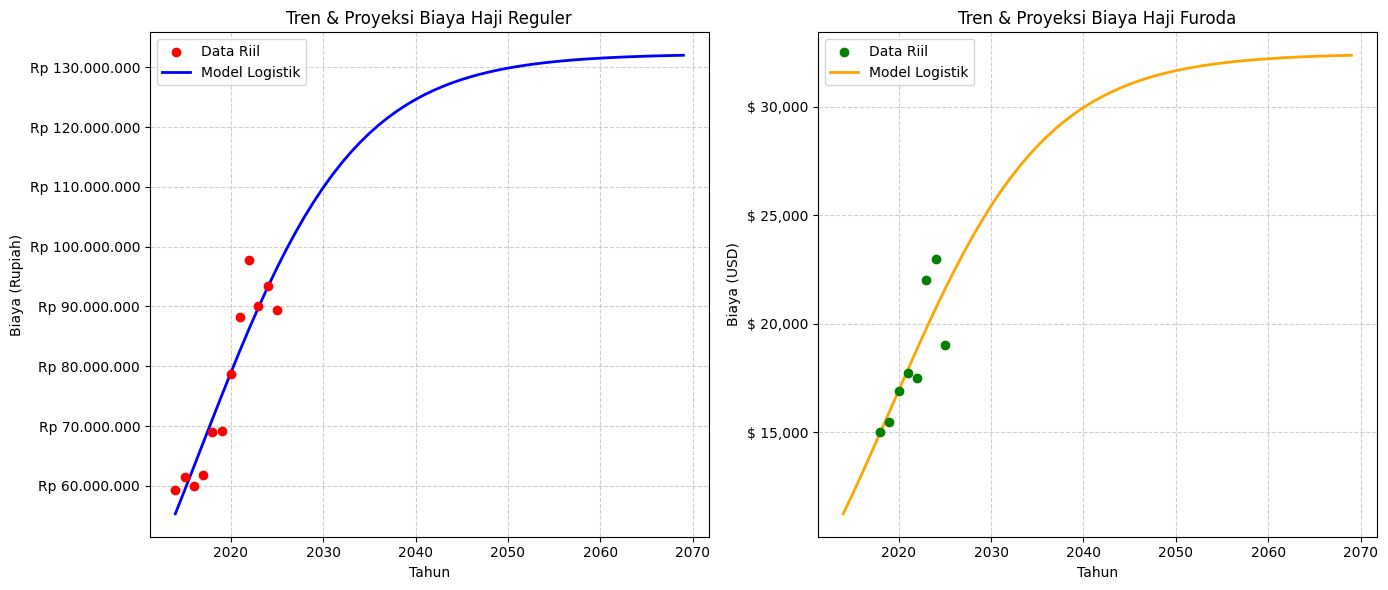

In [ ]:
import matplotlib.ticker as mtick

# --- TAHAP 5: VISUALISASI HASIL

plt.figure(figsize=(14, 6))

# 1. Plot Reguler (Sumbu Y dalam Rupiah)
ax1 = plt.subplot(1, 2, 1)
plt.scatter(df_reg_clean['Tahun'], y_reg, color='red', label='Data Riil', zorder=3)
plt.plot(tahun_proyeksi, pred_reg, label='Model Logistik', color='blue', linewidth=2)

# Format Sumbu Y ke Rupiah
fmt_idr = 'Rp {:,.0f}'
tick_idr = mtick.FuncFormatter(lambda x, pos: fmt_idr.format(x).replace(',', '.')) # Menggunakan titik sebagai pemisah ribuan
ax1.yaxis.set_major_formatter(tick_idr)

plt.title('Tren & Proyeksi Biaya Haji Reguler')
plt.xlabel('Tahun')
plt.ylabel('Biaya (Rupiah)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 2. Plot Furoda (Sumbu Y dalam Dollar)
ax2 = plt.subplot(1, 2, 2)
plt.scatter(df_fur_clean['Tahun'], y_fur, color='green', label='Data Riil', zorder=3)
plt.plot(tahun_proyeksi, pred_fur, label='Model Logistik', color='orange', linewidth=2)

# Format Sumbu Y ke Dollar
fmt_usd = '$ {:,.0f}'
tick_usd = mtick.FuncFormatter(lambda x, pos: fmt_usd.format(x))
ax2.yaxis.set_major_formatter(tick_usd)

plt.title('Tren & Proyeksi Biaya Haji Furoda')
plt.xlabel('Tahun')
plt.ylabel('Biaya (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def get_dynamic_kurs_avg(target_year):
    # 1. Hitung selisih bulan dari data kurs terakhir ke akhir tahun target
    last_date_kurs = data_kurs.index[-1]
    n_bulan = (target_year - last_date_kurs.year) * 12 + (12 - last_date_kurs.month)

    # 2. Forecast kurs menggunakan model Holt-Winters yang sudah di-fit sebelumnya
    prediksi_kurs_dynamic = model_fit.forecast(n_bulan)

    # 3. Buat range tanggal untuk hasil forecast agar bisa difilter berdasarkan tahun
    future_dates = pd.date_range(start=last_date_kurs + pd.DateOffset(months=1),
                                  periods=n_bulan, freq='ME')

    df_temp_kurs = pd.DataFrame({'Kurs': prediksi_kurs_dynamic.values}, index=future_dates)

    # 4. Ambil rata-rata kurs pada tahun target saja
    kurs_avg = df_temp_kurs[df_temp_kurs.index.year == target_year]['Kurs'].mean()

    # Jika tahun target sangat jauh atau ada kendala index, ambil nilai terakhir
    if np.isnan(kurs_avg):
        kurs_avg = prediksi_kurs_dynamic.values[-1]

    return kurs_avg

In [ ]:
# --- FUNGSI 1: HAJI REGULER (IDR) ---
def prediksi_haji_reguler(target_year):
    """Prediksi Haji Reguler menggunakan Model Logistik (Input & Output IDR)"""
    # t_reg menggunakan referensi tahun 2014 (t=0)
    t = target_year - 2014

    # Menggunakan parameter popt_reg yang sudah di-fit sebelumnya
    harga_idr = logistic_model(t, *popt_reg)
    return harga_idr


# --- FUNGSI 2: HAJI PLUS (USD -> IDR) ---
def prediksi_haji_plus(target_year):
    """Prediksi Haji Plus (Konstan $8.000) dikonversi ke IDR secara dinamis"""
    harga_usd_konstan = 8000

    # Ambil rata-rata kurs tahun target secara dinamis
    kurs_konversi = get_dynamic_kurs_avg(target_year)

    harga_idr = harga_usd_konstan * kurs_konversi
    return harga_idr


# --- FUNGSI 3: HAJI FURODA (USD -> IDR) ---
def prediksi_haji_furoda(target_year):
    """Prediksi Haji Furoda menggunakan Model Logistik (USD) dikonversi ke IDR"""
    # t_fur menggunakan referensi tahun 2014 (t=0)
    t = target_year - 2014

    # 1. Hitung harga dalam USD menggunakan model logistik furoda
    harga_usd = logistic_model(t, *popt_fur)

    # 2. Ambil rata-rata kurs tahun target secara dinamis
    kurs_konversi = get_dynamic_kurs_avg(target_year)

    # 3. Konversi ke Rupiah
    harga_idr = harga_usd * kurs_konversi
    return harga_idr

In [ ]:
tahun_rencana = 2200

# Eksekusi Fungsi
biaya_reg = prediksi_haji_reguler(tahun_rencana)
biaya_plus = prediksi_haji_plus(tahun_rencana)
biaya_fur = prediksi_haji_furoda(tahun_rencana)

print(f"--- PROYEKSI BIAYA HAJI TAHUN {tahun_rencana} ---")
print(f"1. Haji Reguler : Rp {biaya_reg:,.0f}")
print(f"2. Haji Plus    : Rp {biaya_plus:,.0f}")
print(f"3. Haji Furoda  : Rp {biaya_fur:,.0f}")

--- PROYEKSI BIAYA HAJI TAHUN 2200 ---
1. Haji Reguler : Rp 132,260,792
2. Haji Plus    : Rp 385,207,646
3. Haji Furoda  : Rp 1,562,122,070


# Decision Support System

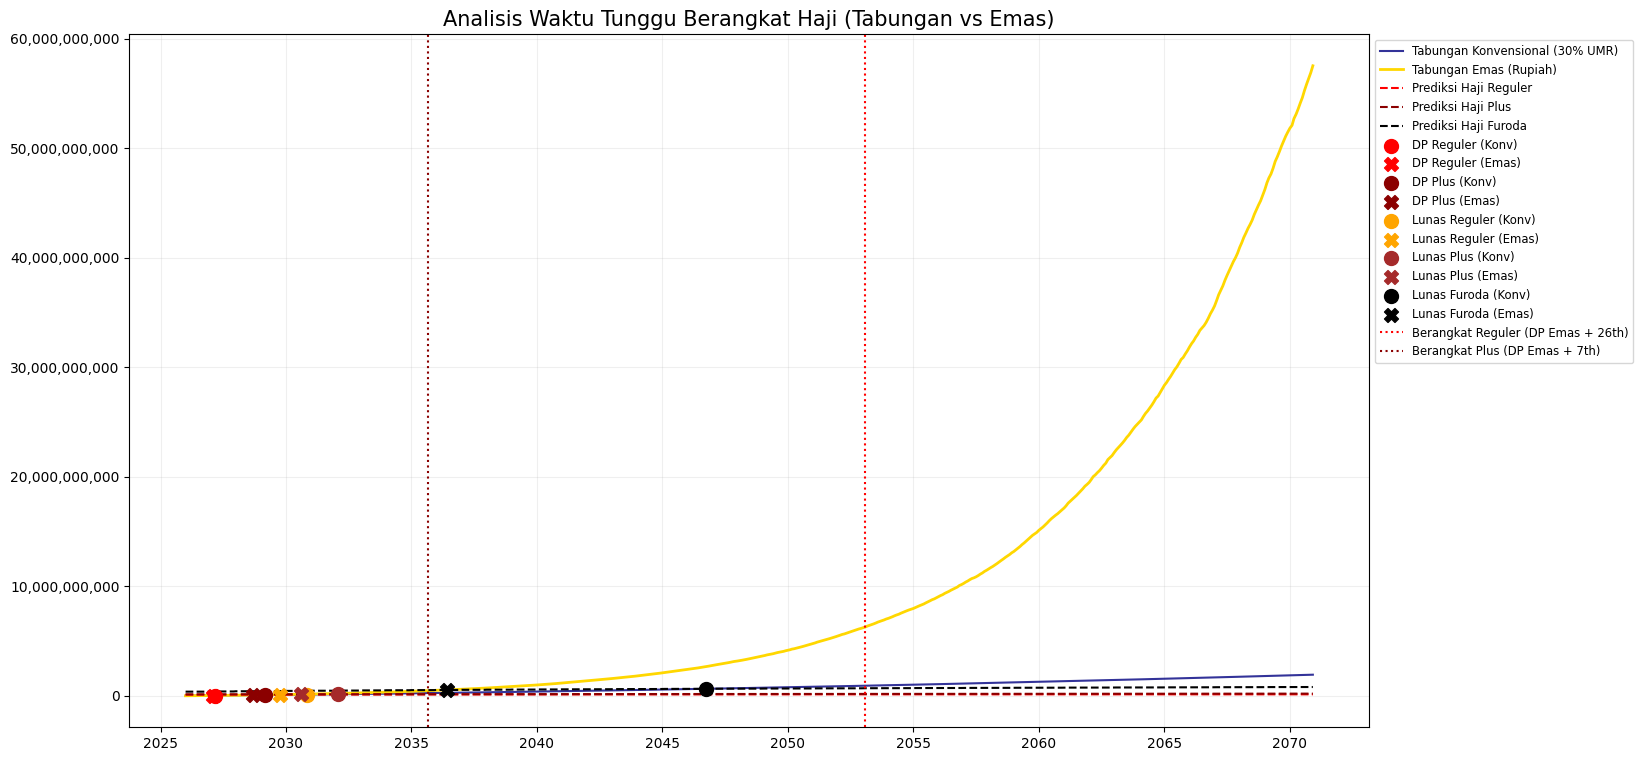

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def jalankan_simulasi_akhir(start_year=2026, end_year=2070):
    # 1. Persiapan Timeline & Data Prediksi
    bulan_simulasi = pd.date_range(start=f'{start_year}-01-01', end=f'{end_year}-12-01', freq='MS')
    df_umr_proj = predict_future_umr(model_umr, df_umr, end_year).set_index('Tahun')
    dates_gold, gold_idr_matrix, _ = dapatkan_prediksi_tahunan(end_year)
    df_gold_proj = pd.DataFrame({'Harga_IDR_gr': np.mean(gold_idr_matrix, axis=1)}, index=dates_gold)

    # Inisialisasi Saldo
    tab_konv = 0
    gram_emas = 0

    # Data untuk Plotting
    history = []

    # Milestones (Penyimpanan Titik Penting)
    m = {
        'Konv': {'Reg_DP': None, 'Reg_Lunas': None, 'Plus_DP': None, 'Plus_Lunas': None, 'Fur_Lunas': None},
        'Emas': {'Reg_DP': None, 'Reg_Lunas': None, 'Plus_DP': None, 'Plus_Lunas': None, 'Fur_Lunas': None}
    }

    for t in bulan_simulasi:
        curr_year = t.year
        # A. Update Tabungan (30% UMR)
        simpanan_bln = 0.3 * df_umr_proj.loc[curr_year, 'UMR_Prediksi']
        tab_konv += simpanan_bln

        harga_emas = df_gold_proj.loc[t, 'Harga_IDR_gr']
        gram_emas += simpanan_bln / harga_emas
        tab_emas = gram_emas * harga_emas

        # B. Update Biaya Haji & Kurs
        kurs = get_dynamic_kurs_avg(curr_year)
        b_reg = prediksi_haji_reguler(curr_year)
        b_plus = prediksi_haji_plus(curr_year)
        b_fur = prediksi_haji_furoda(curr_year)

        dp_reg = 25_000_000
        dp_plus = 4000 * kurs
        sisa_plus = 4000 * kurs # Pelunasan Plus ($8k - $4k)

        # C. Logika Pengecekan Target (Konvensional)
        if m['Konv']['Reg_DP'] is None and tab_konv >= dp_reg: m['Konv']['Reg_DP'] = (t, tab_konv)
        if m['Konv']['Plus_DP'] is None and tab_konv >= dp_plus: m['Konv']['Plus_DP'] = (t, tab_konv)
        if m['Konv']['Reg_Lunas'] is None and tab_konv >= b_reg: m['Konv']['Reg_Lunas'] = (t, tab_konv)
        if m['Konv']['Plus_Lunas'] is None and tab_konv >= b_plus: m['Konv']['Plus_Lunas'] = (t, tab_konv)
        if m['Konv']['Fur_Lunas'] is None and tab_konv >= b_fur: m['Konv']['Fur_Lunas'] = (t, tab_konv)

        # D. Logika Pengecekan Target (Emas)
        if m['Emas']['Reg_DP'] is None and tab_emas >= dp_reg: m['Emas']['Reg_DP'] = (t, tab_emas)
        if m['Emas']['Plus_DP'] is None and tab_emas >= dp_plus: m['Emas']['Plus_DP'] = (t, tab_emas)
        if m['Emas']['Reg_Lunas'] is None and tab_emas >= b_reg: m['Emas']['Reg_Lunas'] = (t, tab_emas)
        if m['Emas']['Plus_Lunas'] is None and tab_emas >= b_plus: m['Emas']['Plus_Lunas'] = (t, tab_emas)
        if m['Emas']['Fur_Lunas'] is None and tab_emas >= b_fur: m['Emas']['Fur_Lunas'] = (t, tab_emas)

        history.append({
            'T': t, 'Konv': tab_konv, 'Emas': tab_emas,
            'B_Reg': b_reg, 'B_Plus': b_plus, 'B_Fur': b_fur,
            'DP_R': dp_reg, 'DP_P': dp_plus
        })

    df_h = pd.DataFrame(history)

    # --- VISUALISASI ---
    plt.figure(figsize=(16, 9))
    plt.plot(df_h['T'], df_h['Konv'], label='Tabungan Konvensional (30% UMR)', color='navy', alpha=0.8)
    plt.plot(df_h['T'], df_h['Emas'], label='Tabungan Emas (Rupiah)', color='gold', linewidth=2)
    plt.plot(df_h['T'], df_h['B_Reg'], label='Prediksi Haji Reguler', color='red', linestyle='--')
    plt.plot(df_h['T'], df_h['B_Plus'], label='Prediksi Haji Plus', color='darkred', linestyle='--')
    plt.plot(df_h['T'], df_h['B_Fur'], label='Prediksi Haji Furoda', color='black', linestyle='--')

    # Plot Titik-Titik Milestone
    styles = [
        (m['Konv']['Reg_DP'], 'red', 'o', 'DP Reguler (Konv)'),
        (m['Emas']['Reg_DP'], 'red', 'X', 'DP Reguler (Emas)'),
        (m['Konv']['Plus_DP'], 'darkred', 'o', 'DP Plus (Konv)'),
        (m['Emas']['Plus_DP'], 'darkred', 'X', 'DP Plus (Emas)'),
        (m['Konv']['Reg_Lunas'], 'orange', 'o', 'Lunas Reguler (Konv)'),
        (m['Emas']['Reg_Lunas'], 'orange', 'X', 'Lunas Reguler (Emas)'),
        (m['Konv']['Plus_Lunas'], 'brown', 'o', 'Lunas Plus (Konv)'),
        (m['Emas']['Plus_Lunas'], 'brown', 'X', 'Lunas Plus (Emas)'),
        (m['Konv']['Fur_Lunas'], 'black', 'o', 'Lunas Furoda (Konv)'),
        (m['Emas']['Fur_Lunas'], 'black', 'X', 'Lunas Furoda (Emas)')
    ]

    for point, color, marker, label in styles:
        if point: plt.scatter(point[0], point[1], color=color, marker=marker, s=100, label=label, zorder=5)

    # Garis Vertikal Keberangkatan (Berdasarkan Emas - karena biasanya lebih cepat)
    if m['Emas']['Reg_DP']:
        t_brkt_reg = m['Emas']['Reg_DP'][0] + pd.DateOffset(years=26)
        plt.axvline(t_brkt_reg, color='red', linestyle=':', label='Berangkat Reguler (DP Emas + 26th)')
    if m['Emas']['Plus_DP']:
        t_brkt_plus = m['Emas']['Plus_DP'][0] + pd.DateOffset(years=7)
        plt.axvline(t_brkt_plus, color='darkred', linestyle=':', label='Berangkat Plus (DP Emas + 7th)')

    plt.title('Analisis Waktu Tunggu Berangkat Haji (Tabungan vs Emas)', fontsize=15)
    plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
    plt.grid(True, alpha=0.2)
    plt.show()

    return m

# Eksekusi
milestones = jalankan_simulasi_akhir()

--- ANALISIS WAKTU TUNGGU BERANGKAT (Mulai Menabung 2026) ---
Emas Reguler   : 2053.1 (Lunas DP thn 2027.1, Tunggu 26th)
Emas Plus      : 2035.7 (Lunas DP thn 2028.7, Tunggu 7th)
Emas Furoda    : 2036.3 (Langsung Berangkat saat Lunas)
------------------------------
Tabungan Reguler: 2053.2 (Lunas DP thn 2027.2, Tunggu 26th)
Tabungan Plus   : 2036.2 (Lunas DP thn 2029.2, Tunggu 7th)
Tabungan Furoda : 2046.8 (Langsung Berangkat saat Lunas)


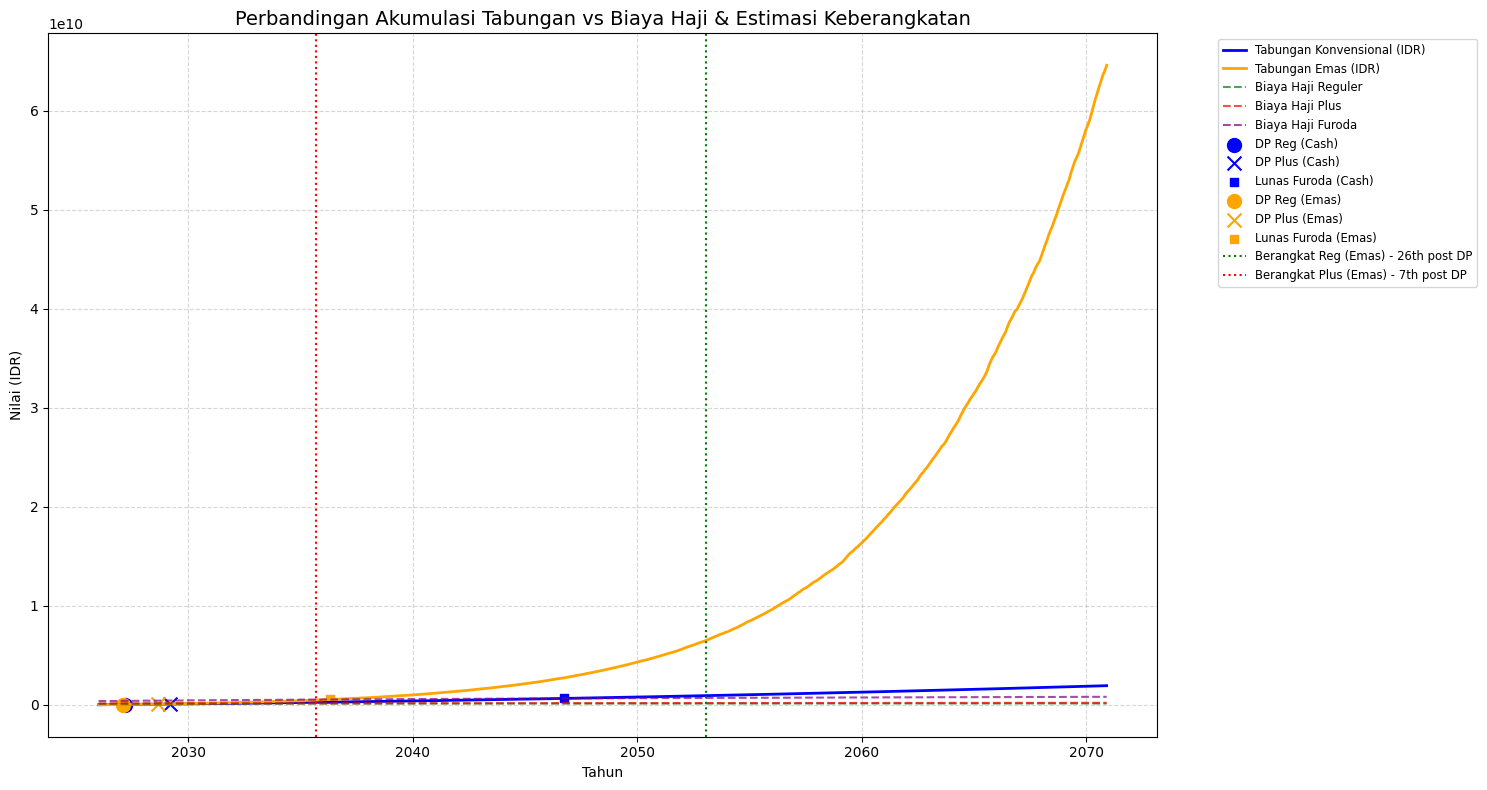

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PERSIAPAN DATA PROYEKSI (2026 - 2070)
# ==========================================
tahun_mulai = 2026
tahun_akhir = 2070
range_tahun = np.arange(tahun_mulai, tahun_akhir + 1)
n_bulan = len(range_tahun) * 12

# A. Ambil Proyeksi Kurs & Emas (Bulanan)
# Menggunakan fungsi yang sudah ada untuk mendapatkan data
dates_future, results_idr_gr_sim, _ = dapatkan_prediksi_tahunan(tahun_akhir)
# Ambil rata-rata simulasi emas sebagai benchmark
harga_emas_bulanan = np.mean(results_idr_gr_sim, axis=1)
# Ambil kurs bulanan
kurs_bulanan = model_fit.forecast(len(harga_emas_bulanan)).values

# B. Ambil Proyeksi UMR (Tahunan ke Bulanan)
df_umr_future = predict_future_umr(model_umr, df_umr, tahun_akhir)
umr_map = df_umr_future.set_index('Tahun')['UMR_Prediksi'].to_dict()

# C. Ambil Proyeksi Biaya Haji (Tahunan)
biaya_haji = {
    'reg': [prediksi_haji_reguler(t) for t in range_tahun],
    'plus': [prediksi_haji_plus(t) for t in range_tahun],
    'fur': [prediksi_haji_furoda(t) for t in range_tahun]
}

# ==========================================
# 2. SIMULASI TABUNGAN (MULAI 2026)
# ==========================================
tabungan_idr = 0
tabungan_emas_gr = 0
catatan_simulasi = []

# Status Milestone
milestones = {
    'cash_reg_dp': None, 'cash_reg_lunas': None,
    'cash_plus_dp': None, 'cash_plus_lunas': None,
    'cash_fur_lunas': None,
    'gold_reg_dp': None, 'gold_reg_lunas': None,
    'gold_plus_dp': None, 'gold_plus_lunas': None,
    'gold_fur_lunas': None
}

idx_bulan = 0
for t_idx, thn in enumerate(range_tahun):
    # Biaya tahun ini
    biaya_reg = biaya_haji['reg'][t_idx]
    biaya_plus = biaya_haji['plus'][t_idx]
    biaya_fur = biaya_haji['fur'][t_idx]

    dp_reg_idr = 25000000
    dp_plus_idr = 4000 * kurs_bulanan[idx_bulan] # DP $4000

    for bln in range(12):
        if idx_bulan >= len(harga_emas_bulanan): break

        # 1. Nabung 30% UMR
        gaji_saat_ini = umr_map.get(thn, umr_map[max(umr_map.keys())])
        simpanan_bulanan = 0.30 * gaji_saat_ini

        # Update Tabungan Cash
        tabungan_idr += simpanan_bulanan

        # Update Tabungan Emas
        harga_emas_now = harga_emas_bulanan[idx_bulan]
        tabungan_emas_gr += (simpanan_bulanan / harga_emas_now)
        val_emas_idr = tabungan_emas_gr * harga_emas_now

        # 2. Cek Milestone Cash
        if milestones['cash_reg_dp'] is None and tabungan_idr >= dp_reg_idr:
            milestones['cash_reg_dp'] = thn + (bln/12)
        if milestones['cash_plus_dp'] is None and tabungan_idr >= dp_plus_idr:
            milestones['cash_plus_dp'] = thn + (bln/12)
        if milestones['cash_reg_lunas'] is None and tabungan_idr >= biaya_reg:
            milestones['cash_reg_lunas'] = thn + (bln/12)
        if milestones['cash_plus_lunas'] is None and tabungan_idr >= biaya_plus:
            milestones['cash_plus_lunas'] = thn + (bln/12)
        if milestones['cash_fur_lunas'] is None and tabungan_idr >= biaya_fur:
            milestones['cash_fur_lunas'] = thn + (bln/12)

        # 3. Cek Milestone Emas
        if milestones['gold_reg_dp'] is None and val_emas_idr >= dp_reg_idr:
            milestones['gold_reg_dp'] = thn + (bln/12)
        if milestones['gold_plus_dp'] is None and val_emas_idr >= dp_plus_idr:
            milestones['gold_plus_dp'] = thn + (bln/12)
        if milestones['gold_reg_lunas'] is None and val_emas_idr >= biaya_reg:
            milestones['gold_reg_lunas'] = thn + (bln/12)
        if milestones['gold_plus_lunas'] is None and val_emas_idr >= biaya_plus:
            milestones['gold_plus_lunas'] = thn + (bln/12)
        if milestones['gold_fur_lunas'] is None and val_emas_idr >= biaya_fur:
            milestones['gold_fur_lunas'] = thn + (bln/12)

        catatan_simulasi.append({
            'Tahun_Frac': thn + (bln/12),
            'Cash': tabungan_idr,
            'Gold_IDR': val_emas_idr,
            'Reguler': biaya_reg,
            'Plus': biaya_plus,
            'Furoda': biaya_fur
        })
        idx_bulan += 1

df_sim = pd.DataFrame(catatan_simulasi)

# ==========================================
# 3. ANALISIS WAKTU TUNGGU
# ==========================================
def hitung_berangkat(dp_year, lunas_year, tipe):
    if tipe == 'reg':
        if dp_year is None: return "Tidak terjangkau"
        return dp_year + 26
    if tipe == 'plus':
        if dp_year is None: return "Tidak terjangkau"
        return dp_year + 7
    if tipe == 'fur':
        if lunas_year is None: return "Tidak terjangkau"
        return lunas_year
    return "Tidak terjangkau" # Default fallback


berangkat_cash_reg = hitung_berangkat(milestones['cash_reg_dp'], milestones['cash_reg_lunas'], 'reg')
berangkat_gold_reg = hitung_berangkat(milestones['gold_reg_dp'], milestones['gold_reg_lunas'], 'reg')
berangkat_cash_plus = hitung_berangkat(milestones['cash_plus_dp'], milestones['cash_plus_lunas'], 'plus')
berangkat_gold_plus = hitung_berangkat(milestones['gold_plus_dp'], milestones['gold_plus_lunas'], 'plus')
berangkat_cash_fur = hitung_berangkat(None, milestones['cash_fur_lunas'], 'fur') # dp_year is intentionally None for Furoda
berangkat_gold_fur = hitung_berangkat(None, milestones['gold_fur_lunas'], 'fur') # dp_year is intentionally None for Furoda

print(f"--- ANALISIS WAKTU TUNGGU BERANGKAT (Mulai Menabung 2026) ---")
print(f"Emas Reguler   : {berangkat_gold_reg:.1f} (Lunas DP thn {milestones['gold_reg_dp']:.1f}, Tunggu 26th)")
print(f"Emas Plus      : {berangkat_gold_plus:.1f} (Lunas DP thn {milestones['gold_plus_dp']:.1f}, Tunggu 7th)")
print(f"Emas Furoda    : {berangkat_gold_fur:.1f} (Langsung Berangkat saat Lunas)")
print("-" * 30)
print(f"Tabungan Reguler: {berangkat_cash_reg:.1f} (Lunas DP thn {milestones['cash_reg_dp']:.1f}, Tunggu 26th)")
print(f"Tabungan Plus   : {berangkat_cash_plus:.1f} (Lunas DP thn {milestones['cash_plus_dp']:.1f}, Tunggu 7th)")
print(f"Tabungan Furoda : {berangkat_cash_fur:.1f} (Langsung Berangkat saat Lunas)")

# ==========================================
# 4. VISUALISASI
# ==========================================
plt.figure(figsize=(15, 8))

# Line Charts
plt.plot(df_sim['Tahun_Frac'], df_sim['Cash'], label='Tabungan Konvensional (IDR)', color='blue', linewidth=2)
plt.plot(df_sim['Tahun_Frac'], df_sim['Gold_IDR'], label='Tabungan Emas (IDR)', color='orange', linewidth=2)
plt.plot(df_sim['Tahun_Frac'], df_sim['Reguler'], '--', label='Biaya Haji Reguler', color='green', alpha=0.7)
plt.plot(df_sim['Tahun_Frac'], df_sim['Plus'], '--', label='Biaya Haji Plus', color='red', alpha=0.7)
plt.plot(df_sim['Tahun_Frac'], df_sim['Furoda'], '--', label='Biaya Haji Furoda', color='purple', alpha=0.7)

# Titik Milestones Cash
if milestones['cash_reg_dp']: plt.scatter(milestones['cash_reg_dp'], 25000000, color='blue', marker='o', s=100, label='DP Reg (Cash)')
if milestones['cash_plus_dp']: plt.scatter(milestones['cash_plus_dp'], 4000*kurs_bulanan[0], color='blue', marker='x', s=100, label='DP Plus (Cash)')
if milestones['cash_fur_lunas']: plt.scatter(milestones['cash_fur_lunas'], df_sim.loc[df_sim['Tahun_Frac'] >= milestones['cash_fur_lunas'], 'Furoda'].values[0], color='blue', marker='s', label='Lunas Furoda (Cash)')

# Titik Milestones Gold
if milestones['gold_reg_dp']: plt.scatter(milestones['gold_reg_dp'], 25000000, color='orange', marker='o', s=100, label='DP Reg (Emas)')
if milestones['gold_plus_dp']: plt.scatter(milestones['gold_plus_dp'], 4000*kurs_bulanan[0], color='orange', marker='x', s=100, label='DP Plus (Emas)')
if milestones['gold_fur_lunas']: plt.scatter(milestones['gold_fur_lunas'], df_sim.loc[df_sim['Tahun_Frac'] >= milestones['gold_fur_lunas'], 'Furoda'].values[0], color='orange', marker='s', label='Lunas Furoda (Emas)')

# Garis Vertikal Keberangkatan (Contoh untuk Emas)
if berangkat_gold_reg and not isinstance(berangkat_gold_reg, str): plt.axvline(berangkat_gold_reg, color='green', linestyle=':', label='Berangkat Reg (Emas) - 26th post DP')
if berangkat_gold_plus and not isinstance(berangkat_gold_plus, str): plt.axvline(berangkat_gold_plus, color='red', linestyle=':', label='Berangkat Plus (Emas) - 7th post DP')

plt.title("Perbandingan Akumulasi Tabungan vs Biaya Haji & Estimasi Keberangkatan", fontsize=14)
plt.xlabel("Tahun")
plt.ylabel("Nilai (IDR)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


--- TABEL PROYEKSI TABUNGAN VS BIAYA HAJI ---


,Tahun,Tabungan_Konvensional,Tabungan_Emas_IDR,Biaya_Haji_Reguler,Biaya_Haji_Plus,Biaya_Haji_Furoda
0,2026,20770725.6,2.077073e+07,9.948749e+07,1.349341e+08,3.783868e+08
1,2027,42543856.8,4.558302e+07,1.023555e+08,1.363725e+08,3.962431e+08
2,2028,65319393.6,7.400512e+07,1.050412e+08,1.378108e+08,4.136844e+08
3,2029,89097336.0,1.083093e+08,1.075440e+08,1.392492e+08,4.306525e+08
4,2030,113877684.0,1.472637e+08,1.098657e+08,1.406875e+08,4.471018e+08
5,2031,139660437.6,1.932991e+08,1.120104e+08,1.421259e+08,4.629992e+08
6,2032,166445596.8,2.459883e+08,1.139839e+08,1.435642e+08,4.783231e+08
7,2033,194233161.6,3.107336e+08,1.157933e+08,1.450026e+08,4.930627e+08
8,2034,223023132.0,3.810255e+08,1.174469e+08,1.464409e+08,5.072163e+08
9,2035,252815508.0,4.503166e+08,1.189535e+08,1.478793e+08,5.207901e+08



--- ANALISIS WAKTU TUNGGU BERANGKAT (Mulai Menabung 2026) ---

STRATEGI EMAS:
- Haji Reguler: Menabung 1 thn (DP 2027), Berangkat 2053 (Antrian 26 thn)
- Haji Plus   : Menabung 2 thn (DP 2028), Berangkat 2035 (Antrian 7 thn)
- Haji Furoda : Menabung 10 thn, Berangkat 2036 (Tanpa Antri)

STRATEGI KONVENSIONAL:
- Haji Reguler: Menabung 1 thn (DP 2027), Berangkat 2053 (Antrian 26 thn)
- Haji Plus   : Menabung 3 thn (DP 2029), Berangkat 2036 (Antrian 7 thn)
- Haji Furoda : Menabung 20 thn, Berangkat 2046 (Tanpa Antri)


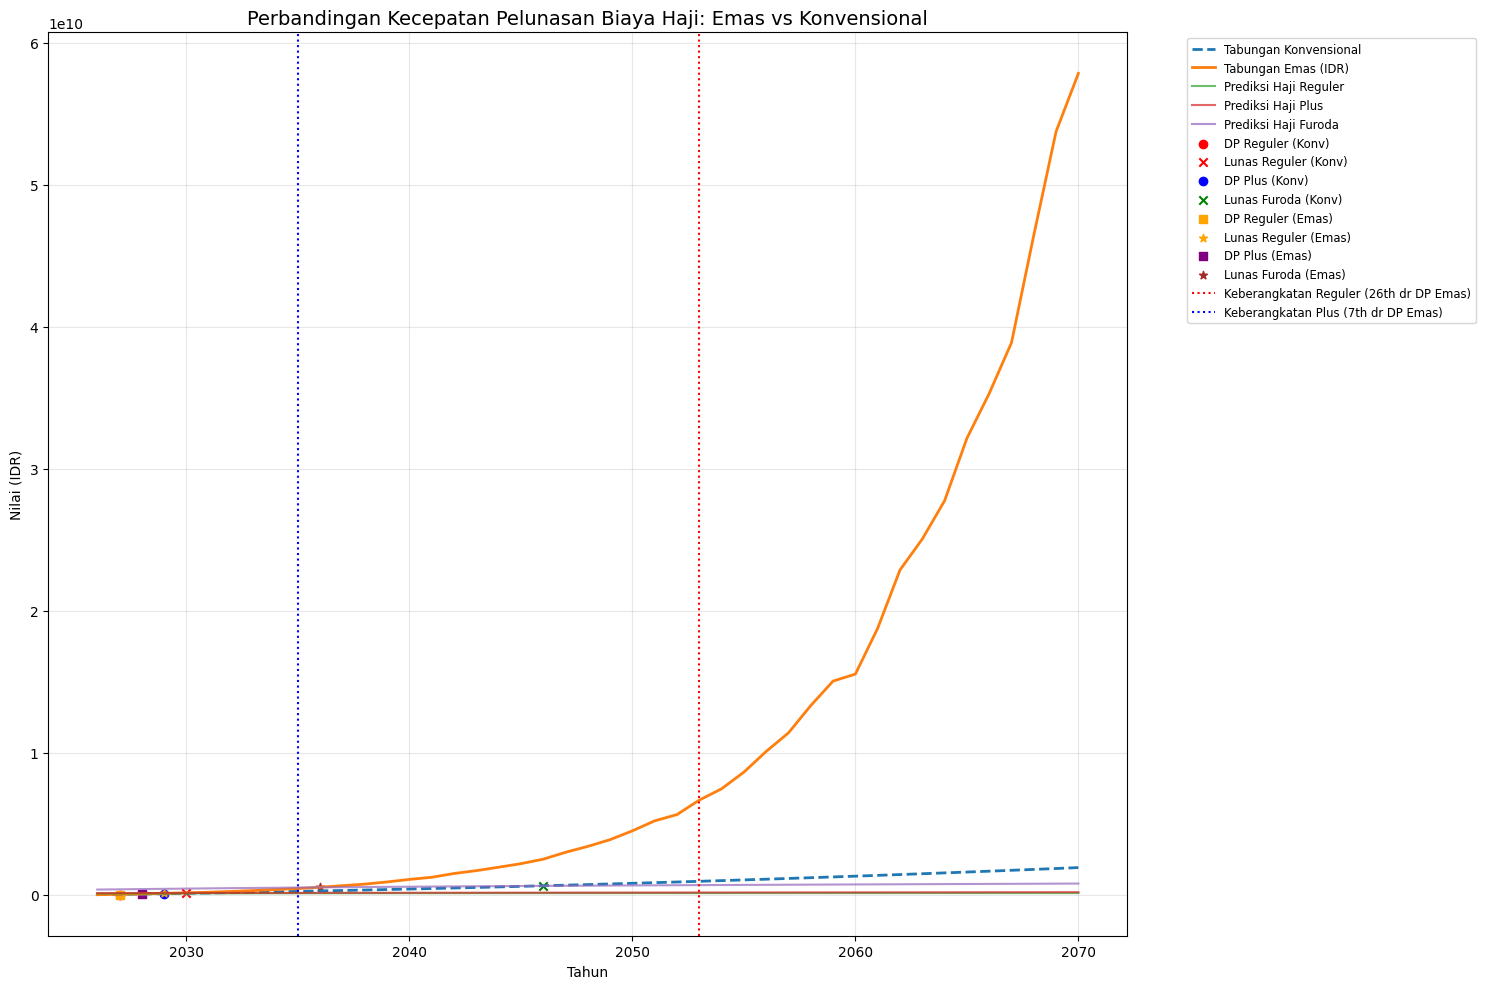


--- PRATINJAU TABEL PROYEKSI (AKHIR TAHUN) ---


,Tahun,Tabungan Konvensional,Tabungan Emas,Harga Haji Reguler,Harga Haji Plus,Harga Haji Furoda
0,2026,20770726.0,21968707.0,99487493.0,134934108.0,378386832.0
1,2027,42543857.0,48072821.0,102355528.0,136372462.0,396243128.0
2,2028,65319394.0,79071600.0,105041246.0,137810816.0,413684412.0
3,2029,89097336.0,115161549.0,107544012.0,139249169.0,430652454.0
4,2030,113877684.0,157654531.0,109865717.0,140687523.0,447101753.0



Data proyeksi tahunan berhasil disimpan ke 'Simulasi_Masa_Tunggu_Haji.xlsx'
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 4.3 ANALISIS STRATEGI MENABUNG DAN WAKTU TUNGGU ---

def analisis_keberangkatan():
    start_year = 2026
    end_year = 2070 # Proyeksi hingga 2070 untuk melihat masa tunggu reguler

    # 1. Proyeksi UMR Long-Term (Gunakan model yang sudah ada)
    # Kita asumsikan model_umr dan df_umr sudah didefinisikan di sel sebelumnya
    df_umr_long = predict_future_umr(model_umr, df_umr, end_year)

    data_tahunan = []

    # Variabel Kumulatif
    tabungan_konv = 0
    gram_emas_akumulasi = 0

    # Variabel untuk mencatat milestone (Tahun tercapai)
    milestones = {
        'DP_Reg_Konv': None, 'Lunas_Reg_Konv': None,
        'DP_Plus_Konv': None, 'Lunas_Plus_Konv': None,
        'Lunas_Fur_Konv': None,
        'DP_Reg_Emas': None, 'Lunas_Reg_Emas': None,
        'DP_Plus_Emas': None, 'Lunas_Plus_Emas': None,
        'Lunas_Fur_Emas': None
    }

    for year in range(start_year, end_year + 1):
        # A. Dapatkan Nilai Prediksi Tahun Berjalan
        # UMR & Tabungan (30% dari gaji)
        umr_tahun_ini = df_umr_long[df_umr_long['Tahun'] == year]['UMR_Prediksi'].values[0]
        tabungan_bulanan = 0.30 * umr_tahun_ini
        tabungan_tahunan = tabungan_bulanan * 12

        # Kurs & Harga Emas
        # Menggunakan fungsi yang Anda sediakan
        _, _, harga_emas_gr = dapatkan_prediksi_tahunan(year)
        kurs_saat_ini = get_dynamic_kurs_avg(year)

        # Biaya Haji
        biaya_reg = prediksi_haji_reguler(year)
        biaya_plus = prediksi_haji_plus(year)
        biaya_fur = prediksi_haji_furoda(year)

        # B. Akumulasi Tabungan
        # 1. Konvensional
        tabungan_konv += tabungan_tahunan

        # 2. Emas
        gram_dibeli = tabungan_tahunan / harga_emas_gr
        gram_emas_akumulasi += gram_dibeli
        nilai_emas_idr = gram_emas_akumulasi * harga_emas_gr

        # C. Cek Milestone Pembayaran
        dp_reg_nominal = 25000000
        dp_plus_nominal = 4000 * kurs_saat_ini
        lunas_plus_nominal = 8000 * kurs_saat_ini

        # Logika Pengecekan (Hanya catat tahun pertama kali tercapai)
        # --- KONVENSIONAL ---
        if milestones['DP_Reg_Konv'] is None and tabungan_konv >= dp_reg_nominal:
            milestones['DP_Reg_Konv'] = year
        if milestones['Lunas_Reg_Konv'] is None and tabungan_konv >= biaya_reg:
            milestones['Lunas_Reg_Konv'] = year

        if milestones['DP_Plus_Konv'] is None and tabungan_konv >= dp_plus_nominal:
            milestones['DP_Plus_Konv'] = year
        if milestones['Lunas_Plus_Konv'] is None and tabungan_konv >= lunas_plus_nominal:
            milestones['Lunas_Plus_Konv'] = year

        if milestones['Lunas_Fur_Konv'] is None and tabungan_konv >= biaya_fur:
            milestones['Lunas_Fur_Konv'] = year

        # --- EMAS ---
        if milestones['DP_Reg_Emas'] is None and nilai_emas_idr >= dp_reg_nominal:
            milestones['DP_Reg_Emas'] = year
        if milestones['Lunas_Reg_Emas'] is None and nilai_emas_idr >= biaya_reg:
            milestones['Lunas_Reg_Emas'] = year

        if milestones['DP_Plus_Emas'] is None and nilai_emas_idr >= dp_plus_nominal:
            milestones['DP_Plus_Emas'] = year
        if milestones['Lunas_Plus_Emas'] is None and nilai_emas_idr >= lunas_plus_nominal:
            milestones['Lunas_Plus_Emas'] = year

        if milestones['Lunas_Fur_Emas'] is None and nilai_emas_idr >= biaya_fur:
            milestones['Lunas_Fur_Emas'] = year

        # Simpan data untuk tabel
        data_tahunan.append({
            'Tahun': year,
            'Tabungan_Konvensional': tabungan_konv,
            'Tabungan_Emas_IDR': nilai_emas_idr,
            'Biaya_Haji_Reguler': biaya_reg,
            'Biaya_Haji_Plus': biaya_plus,
            'Biaya_Haji_Furoda': biaya_fur
        })

    return pd.DataFrame(data_tahunan), milestones

# --- EKSEKUSI & TAMPILKAN HASIL ---
df_hasil, m = analisis_keberangkatan()

print("\n--- TABEL PROYEKSI TABUNGAN VS BIAYA HAJI ---")
display(df_hasil.head(15)) # Tampilkan 15 tahun pertama

# --- ANALISIS WAKTU TUNGGU ---
print(f"\n--- ANALISIS WAKTU TUNGGU BERANGKAT (Mulai Menabung 2026) ---")

def cetak_analisis(nama_metode, dp_reg, lunas_reg, dp_plus, lunas_plus, lunas_fur):
    start = 2026
    # Reguler: DP + 26 tahun
    tahun_berangkat_reg = dp_reg + 26 if dp_reg else "Tidak tercapai"
    # Plus: DP + 7 tahun (Asumsi pelunasan dilakukan sebelum berangkat)
    tahun_berangkat_plus = dp_plus + 7 if dp_plus else "Tidak tercapai"
    # Furoda: Begitu lunas langsung berangkat
    tahun_berangkat_fur = lunas_fur if lunas_fur else "Tidak tercapai"

    print(f"\nSTRATEGI {nama_metode.upper()}:")
    print(f"- Haji Reguler: Menabung {dp_reg-start if dp_reg else '?'} thn (DP {dp_reg}), Berangkat {tahun_berangkat_reg} (Antrian 26 thn)")
    print(f"- Haji Plus   : Menabung {dp_plus-start if dp_plus else '?'} thn (DP {dp_plus}), Berangkat {tahun_berangkat_plus} (Antrian 7 thn)")
    print(f"- Haji Furoda : Menabung {lunas_fur-start if lunas_fur else '?'} thn, Berangkat {tahun_berangkat_fur} (Tanpa Antri)")

cetak_analisis("Emas", m['DP_Reg_Emas'], m['Lunas_Reg_Emas'], m['DP_Plus_Emas'], m['Lunas_Plus_Emas'], m['Lunas_Fur_Emas'])
cetak_analisis("Konvensional", m['DP_Reg_Konv'], m['Lunas_Reg_Konv'], m['DP_Plus_Konv'], m['Lunas_Plus_Konv'], m['Lunas_Fur_Konv'])

# --- VISUALISASI ---
plt.figure(figsize=(15, 10))

# Garis Biaya & Tabungan
plt.plot(df_hasil['Tahun'], df_hasil['Tabungan_Konvensional'], label='Tabungan Konvensional', linewidth=2, linestyle='--')
plt.plot(df_hasil['Tahun'], df_hasil['Tabungan_Emas_IDR'], label='Tabungan Emas (IDR)', linewidth=2)
plt.plot(df_hasil['Tahun'], df_hasil['Biaya_Haji_Reguler'], label='Prediksi Haji Reguler', alpha=0.7)
plt.plot(df_hasil['Tahun'], df_hasil['Biaya_Haji_Plus'], label='Prediksi Haji Plus', alpha=0.7)
plt.plot(df_hasil['Tahun'], df_hasil['Biaya_Haji_Furoda'], label='Prediksi Haji Furoda', alpha=0.7)

# Titik-titik Milestone (Pelunasan & DP)
# Konvensional
if m['DP_Reg_Konv']: plt.scatter(m['DP_Reg_Konv'], 25000000, color='red', marker='o', label='DP Reguler (Konv)')
if m['Lunas_Reg_Konv']: plt.scatter(m['Lunas_Reg_Konv'], df_hasil.loc[df_hasil['Tahun']==m['Lunas_Reg_Konv'], 'Biaya_Haji_Reguler'], color='red', marker='x', label='Lunas Reguler (Konv)')
if m['DP_Plus_Konv']: plt.scatter(m['DP_Plus_Konv'], 70000000, color='blue', marker='o', label='DP Plus (Konv)')
if m['Lunas_Fur_Konv']: plt.scatter(m['Lunas_Fur_Konv'], df_hasil.loc[df_hasil['Tahun']==m['Lunas_Fur_Konv'], 'Biaya_Haji_Furoda'], color='green', marker='x', label='Lunas Furoda (Konv)')

# Emas
if m['DP_Reg_Emas']: plt.scatter(m['DP_Reg_Emas'], 25000000, color='orange', marker='s', label='DP Reguler (Emas)')
if m['Lunas_Reg_Emas']: plt.scatter(m['Lunas_Reg_Emas'], df_hasil.loc[df_hasil['Tahun']==m['Lunas_Reg_Emas'], 'Biaya_Haji_Reguler'], color='orange', marker='*', label='Lunas Reguler (Emas)')
if m['DP_Plus_Emas']: plt.scatter(m['DP_Plus_Emas'], 70000000, color='purple', marker='s', label='DP Plus (Emas)')
if m['Lunas_Fur_Emas']: plt.scatter(m['Lunas_Fur_Emas'], df_hasil.loc[df_hasil['Tahun']==m['Lunas_Fur_Emas'], 'Biaya_Haji_Furoda'], color='brown', marker='*', label='Lunas Furoda (Emas)')

# Garis Vertikal Keberangkatan (Contoh dari strategi Emas sebagai perwakilan)
if m['DP_Reg_Emas']:
    plt.axvline(x=m['DP_Reg_Emas'] + 26, color='red', linestyle=':', label='Keberangkatan Reguler (26th dr DP Emas)')
if m['DP_Plus_Emas']:
    plt.axvline(x=m['DP_Plus_Emas'] + 7, color='blue', linestyle=':', label='Keberangkatan Plus (7th dr DP Emas)')

plt.title('Perbandingan Kecepatan Pelunasan Biaya Haji: Emas vs Konvensional', fontsize=14)
plt.xlabel('Tahun')
plt.ylabel('Nilai (IDR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 5. PEMBUATAN TABEL DAN EXPORT EXCEL
# ==========================================

# 1. Tentukan tahun terakhir untuk ditampilkan (berdasarkan keberangkatan terjauh)
daftar_berangkat = [
    berangkat_cash_reg,
    berangkat_gold_reg,
    berangkat_cash_plus,
    berangkat_gold_plus,
    berangkat_cash_fur,
    berangkat_gold_fur
]

# Ambil nilai numerik saja, jika semua "Tidak terjangkau" gunakan tahun_akhir
valid_years = [y for y in daftar_berangkat if isinstance(y, (int, float))]
max_tahun_tampil = int(max(valid_years)) + 1 if valid_years else tahun_akhir

# Ensure max_tahun_tampil goes up to end_year (2070) if the user explicitly requested it.
max_tahun_tampil = max(max_tahun_tampil, tahun_akhir)

# 2. Filter data simulasi hingga tahun keberangkatan
df_export = df_sim[df_sim['Tahun_Frac'] <= max_tahun_tampil].copy()

# 3. Ambil data akhir tahun saja (Desember) agar tabel ringkas
# (Mengambil baris ke-11, 23, 35, dst atau yang Tahun_Frac-nya mendekati integer .91)
df_yearly_temp = df_export.groupby(df_export['Tahun_Frac'].astype(int)).last()
df_yearly_temp.index.name = 'Tahun' # Name the index to become the 'Tahun' column
df_yearly = df_yearly_temp.reset_index() # This will create a 'Tahun' column from the index
df_yearly = df_yearly.drop(columns=['Tahun_Frac']) # Drop the original float 'Tahun_Frac' column

# 4. Rapikan kolom sesuai permintaan
df_yearly = df_yearly.rename(columns={
    'Cash': 'Tabungan Konvensional',
    'Gold_IDR': 'Tabungan Emas',
    'Reguler': 'Harga Haji Reguler',
    'Plus': 'Harga Haji Plus',
    'Furoda': 'Harga Haji Furoda'
})

# Pembulatan agar bersih di Excel
kolom_uang = ['Tabungan Konvensional', 'Tabungan Emas', 'Harga Haji Reguler', 'Harga Haji Plus', 'Harga Haji Furoda']
df_yearly[kolom_uang] = df_yearly[kolom_uang].round(0)

# 5. Tampilkan 5 baris pertama di notebook
print("\n--- PRATINJAU TABEL PROYEKSI (AKHIR TAHUN) ---")
display(df_yearly.head())

# 6. Export ke Excel
nama_file = 'Simulasi_Masa_Tunggu_Haji.xlsx'
df_yearly.to_excel(nama_file, index=False)
print(f"\nData proyeksi tahunan berhasil disimpan ke '{nama_file}'")